<a href="https://colab.research.google.com/github/hasinikondle/DataScience_Task/blob/main/DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DecisionTreeClassifier

In [49]:
# import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [50]:
# loading dataset
df = pd.read_csv("heart.csv")

In [51]:
# display first 5 rows
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [52]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    int64  
 3   cp          303 non-null    int64  
 4   trestbps    303 non-null    int64  
 5   chol        303 non-null    int64  
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     303 non-null    int64  
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    int64  
dtypes: float64(1), int64(14)
memory usage: 35.6 KB


cleaning

In [53]:
# remove unwanted columns
df = df.drop("Unnamed: 0",axis=1)

since data has only numerical cols no need of encoding

Model Training

In [54]:
# divide data into input and output
X = df.drop("target",axis=1)
y = df["target"]

In [55]:
# split the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [56]:
# model training
model = DecisionTreeClassifier(max_depth=5)
model.fit(Xtrain,ytrain)

DecisionTreeClassifier(max_depth=5)

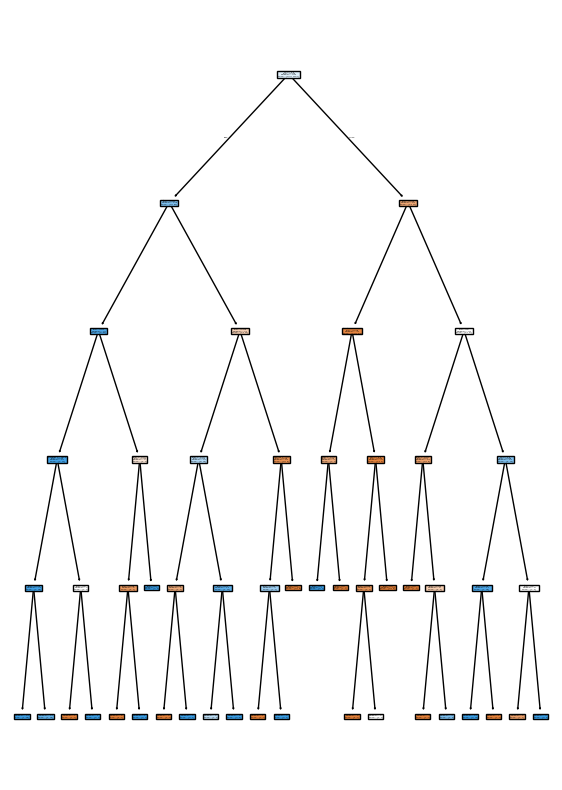

In [57]:
# Tree Classifier
from sklearn.tree import plot_tree
plt.figure(figsize=(7,10))
plot_tree(model,feature_names=df.columns[:-1],filled=True)
plt.show()

Prediction

In [58]:
# prediction
ypred = model.predict(Xtest)
ypred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1])

In [59]:
# confusion matrix printing
confusion_matrix(ytest,ypred)

array([[32,  9],
       [14, 36]])

In [60]:
# classification report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.70      0.78      0.74        41
           1       0.80      0.72      0.76        50

    accuracy                           0.75        91
   macro avg       0.75      0.75      0.75        91
weighted avg       0.75      0.75      0.75        91



In [61]:
new_data = df.iloc[0:1,:-1]
pred = model.predict(new_data)[0]
if pred == 0:
  print("No sign of heart disease")
else:
  print("Yes, sign of heart disease")

Yes, sign of heart disease
